In [1]:
# imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# imports for OLS / Anova
import statsmodels.formula.api as smf
import statsmodels.api as sm

# imports for function
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [3]:
# extract load

In [3]:
ls -lh ./data

Le format du paramŠtre est incorrect - "data".


In [4]:
path = './data/'
csv_path = path + 'clean_openfoodfacts_3.csv'
df = pd.read_csv(csv_path, low_memory=False)

In [5]:
df.rename(columns = {'energy-kcal_100g':'energy_kcal_100g'}, inplace=True)

In [6]:
df.head()

,code,nutrition_grade_fr,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,product_name,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1
0,10187319,d,14.0,0.6,1753.0,0.0100,0.003937,87.7,0.8,Mini Confettis,0.9,6.7,12.41,One-dish meals,Composite foods
1,10207260,d,14.0,9.5,2406.0,0.0030,0.001181,50.3,2.9,Praliné Amande Et Noisette,3.9,6.7,12.41,One-dish meals,Composite foods
2,40608754,e,13.0,0.0,177.0,0.0254,0.010000,10.4,0.0,"Pepsi, Nouveau goût !",0.0,0.0,10.40,Sweetened beverages,Beverages
3,69161025,d,15.0,7.5,1079.0,0.8000,0.314961,1.0,11.0,Tarte Poireaux Et Lardons,1.4,6.7,12.41,One-dish meals,Composite foods
4,87177756,e,13.0,0.0,177.0,0.1000,0.039370,10.4,0.0,7Up,0.1,0.0,10.40,Sweetened beverages,Beverages


In [7]:
df.shape

(46254, 15)

In [9]:
df.describe()

,code,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
count,4.625400e+04,46254.000000,46254.000000,46254.000000,46254.000000,46254.000000,46254.000000,46254.000000,46254.000000,46254.000000,46254.000000
mean,3.819760e+12,7.458058,7.997487,903.026066,1.030215,0.406654,8.405316,4.261906,1.734880,8.320786,15.305030
std,4.428525e+12,7.511161,8.172165,664.687971,2.218823,0.902549,14.179234,7.071811,3.635696,10.287734,16.857723
min,1.756000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.248830e+12,0.000000,1.500000,347.000000,0.080000,0.031496,0.800000,0.200000,0.000000,2.000000,5.000000
50%,3.329770e+12,4.000000,5.800000,755.000000,0.650000,0.255906,2.900000,1.400000,0.900000,6.700000,12.410000
75%,3.608581e+12,13.000000,12.000000,1400.000000,1.300000,0.511811,10.000000,5.000000,2.100000,7.800000,13.000000
max,3.661112e+14,36.000000,90.000000,3761.000000,68.200000,49.212598,100.000000,100.000000,100.000000,92.000000,100.000000


In [10]:
#missing data
df.isnull().sum()

code                       0
nutrition_grade_fr         0
nutrition-score-fr_100g    0
proteins_100g              0
energy_100g                0
salt_100g                  0
sodium_100g                0
sugars_100g                0
saturated-fat_100g         0
product_name               0
fiber_100g                 0
fat_100g                   0
carbohydrates_100g         0
pnns_groups_2              0
pnns_groups_1              0
dtype: int64

# Univariate analysis

In [11]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46254 entries, 0 to 46253
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   code                     46254 non-null  int64  
 1   nutrition_grade_fr       46254 non-null  object 
 2   nutrition-score-fr_100g  46254 non-null  float64
 3   proteins_100g            46254 non-null  float64
 4   energy_100g              46254 non-null  float64
 5   salt_100g                46254 non-null  float64
 6   sodium_100g              46254 non-null  float64
 7   sugars_100g              46254 non-null  float64
 8   saturated-fat_100g       46254 non-null  float64
 9   product_name             46254 non-null  object 
 10  fiber_100g               46254 non-null  float64
 11  fat_100g                 46254 non-null  float64
 12  carbohydrates_100g       46254 non-null  float64
 13  pnns_groups_2            46254 non-null  object 
 14  pnns_groups_1         

## Numerical variables

In [12]:
#num_cols = df.columns[df.dtypes == 'float64']
#num_cols

In [21]:
num_cols = ['fat_100g', 'saturated-fat_100g',
               'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 
               'salt_100g','sodium_100g',
               'fiber_100g', 'nutrition-score-fr_100g']
energy_cols = ['energy_100g']
scores_cols = ['nutrition-score-fr_100g', 'nutrition_grade_fr', 
               #'ecoscore_grade'
              ]

In [22]:
df.dtypes[df.dtypes == 'float64'].size

10

There's 10 numerical variables, that could be split into 3 groups regarding their different units of measurement / orders of magnitude :

- nutrients (less than 100g per 100g)
- energy (less than 900 Cal per 100g)

In [15]:
nutrients = ['fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g']
energy = ['energy-kcal_100g']

##

fats = ['fat_100g', 'saturated-fat_100g']
sugars = ['carbohydrates_100g', 'sugars_100g']
other = ['proteins_100g', 'salt_100g',
       'sodium_100g']

In [16]:
def UVA_numeric2(data, i):
  '''
  Univariate_Analysis_numeric
  takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
  '''
  # calculating descriptives of variable
  mini = data[i].min()
  maxi = data[i].max()
  ran = data[i].max()-data[i].min()
  mean = data[i].mean()
  median = data[i].median()
  st_dev = data[i].std()
  skew = data[i].skew()
  kurt = data[i].kurtosis()

  # calculating points of standard deviation
  points = mean-st_dev, mean+st_dev

  #Plotting the variable with every information
  sns.kdeplot(data[i], shade=True)
  sns.lineplot(points, [0,0], color = 'black', label = "std_dev")
  sns.scatterplot([mini,maxi], [0,0], color = 'orange', label = "min/max")
  sns.scatterplot([mean], [0], color = 'red', label = "mean")
  sns.scatterplot([median], [0], color = 'blue', label = "median")
  plt.xlabel('{}'.format(i), fontsize = 20)
  plt.ylabel('density')
  plt.title('std_dev = {}; kurtosis = {};\nskew = {}; range = {}\nmean = {}; median = {}'.format((round(points[0],2),round(points[1],2)),
                                                                                                   round(kurt,2),
                                                                                                   round(skew,2),
                                                                                                   (round(mini,2),round(maxi,2),round(ran,2)),
                                                                                                   round(mean,2),
                                                                                                   round(median,2)))

In [17]:
# afficher détail Boxplot / UVA_num pour chaque indicateur par ligne

def UVA_num_plus(df, indicators_list):
  
    for i in indicators_list:
        plt.figure(figsize = (15, 20))
        df_indic = df[i]

        plt.subplot(5,2,1)
        sns.boxplot(y=df_indic)
        plt.xlabel(f'{i}', fontsize = 20)


        plt.subplot(5,2,2)
        UVA_numeric2(df, i)


In [18]:
# distributions du data set "cleané"

[Text(0, 0, 'fat_100g'),
 Text(1, 0, 'saturated-fat_100g'),
 Text(2, 0, 'carbohydrates_100g'),
 Text(3, 0, 'sugars_100g'),
 Text(4, 0, 'proteins_100g'),
 Text(5, 0, 'salt_100g'),
 Text(6, 0, 'sodium_100g')]

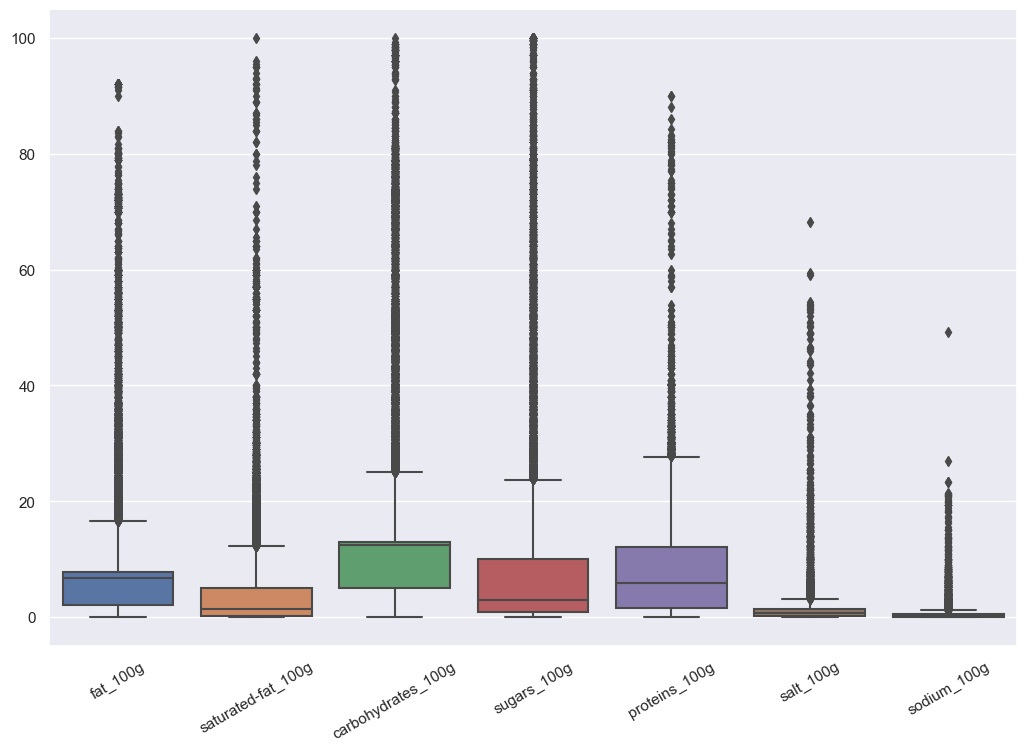

In [19]:
sns.set(rc={'figure.figsize':(12.5,8.27)})
ax = sns.boxplot(data=df[num_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

In [20]:
sns.set(rc={'figure.figsize':(9.7,7.27)})
ax = sns.boxplot(data=df[energy_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

KeyError: "None of [Index(['energy_kcal_100g'], dtype='object')] are in the [columns]"

In [ ]:
UVA_num_plus(df, num_cols)

### Comparison with univariates from un-cleaned data source

In [ ]:
#old_path = path + 'fr.openfoodfacts.org.products.csv'
#columns = ['product_name', 'pnns_groups_1', 'pnns_groups_2', 'code',
#        'fat_100g', 'saturated-fat_100g',
#       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
#       'sodium_100g']

In [ ]:
#df_old = pd.read_csv(old_path, sep='\t', header='infer', on_bad_lines='skip', low_memory=False)

In [ ]:
#df_old = df_old[columns]

In [ ]:
#df_old.shape

In [ ]:
#old_num_cols = df_old.columns[df_old.dtypes == 'float64']
#old_num_cols

In [ ]:
# ce sont les distributions du data set initial !!!

#UVA_num_plus(df_old, old_num_cols)

## Categorical variables

In [ ]:
mylist = df['pnns_groups_1'].unique()
mylist

In [ ]:
n =10

newlist = mylist[:n]
newlist

In [ ]:
cats = ['pnns_groups_1', 'pnns_groups_2']

In [ ]:
# Custom function for easy visualisation of Categorical Variables
def UVA_category(data, var_group, width=7, height=5):

  '''
  Univariate_Analysis_categorical
  takes a group of variables (category) and plot/print all the value_counts and barplot.
  '''
  # setting figure_size
  size = len(var_group)
  plt.figure(figsize = (width*size, height), dpi = 100)

  # for every variable
  for j,i in enumerate(var_group):
    norm_count = data[i].value_counts(normalize = True)
    n_uni = data[i].nunique()

  #Plotting the variable with every information
    plt.subplot(1,size,j+1)
    sns.barplot(norm_count, norm_count.index , order = norm_count.index)
    plt.xlabel('fraction/percent', fontsize = 20)
    plt.ylabel('{}'.format(i), fontsize = 20)
    plt.title('n_uniques = {} \n value counts \n {};'.format(n_uni,norm_count))

In [ ]:
pd.set_option('display.max_rows', 10)
UVA_category(df, ['pnns_groups_1'])

In [ ]:
df['pnns_groups_1'].value_counts()

### pie charts

In [ ]:
# Diagramme en secteurs
#sns.set(font_scale=1.2)
df['pnns_groups_1'].value_counts(normalize=True).plot(kind='pie')
plt.axis('equal')
plt.show()

In [ ]:
#colors = sns.color_palette('pastel')[0:5]

#plt.pie(df['pnns_groups_2'], colors = colors, autopct='%.0f%%')
#plt.show()

# Bi-variate

=> ajouter graphs num / num & cat/cat & num/cat

In [ ]:
df.head()

In [ ]:
# cat / num

In [ ]:
x = df['pnns_groups_1']
y = df['energy_kcal_100g']

In [ ]:
plt.figure(figsize=(18, 15), dpi=80)
plt.xticks(rotation=70)
plt.plot(x, y, 'x')
plt.show()

In [ ]:
# num / num

plt.figure(figsize=(18, 15), dpi=80)
plt.xticks(rotation=70)
x = df['sugars_100g']
y = df['energy_kcal_100g']
plt.plot(x,y, 'x')
plt.show()
# titres
#taille

# Multi-variate


## Correlation Matrix

In [ ]:
num_cols

In [ ]:
plt.figure(figsize=(8,8))
sns.set(font_scale=1.5)
plt.title('Matrice de corrélation de Pearson entre les variables numériques')

corr = df.corr()

mask = np.zeros_like(corr, dtype=np.bool_)
mask[np.triu_indices_from(mask)] = True 

ax = sns.heatmap(corr, mask=mask, vmin=-1, cmap='coolwarm')
plt.show()
sns.set(font_scale=1)

On peut retirer du tableau les informations suivantes :

- **fat_100g** et **saturated-fat_100g** sont fortement corrélés
- **energy-kcal_100g** : forte corrélation avec :
  - fat_100g
  - saturated-fat_100g
  - carbohydrates_100g
  - proteins_100g
- **sodium_100g** et **salt_100g** sont fortement corrélés
- **sugars_100g** sont corrélés avec **carbohydrates_100g**

## Hierarchical clustering / CHA (Classification Hiérarchique Ascendante)

In [ ]:
# Sur le P3, j'ai rajouté ce matin un CHA pour voir plus facilement les relations 
# entre les différents éléments numériques

In [ ]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

plt.figure(figsize=(12,5))
dissimilarity = 1 - abs(corr)
Z = linkage(squareform(dissimilarity), 'complete')

dendrogram(Z, 
           labels=num_cols, 
           orientation='top', 
           leaf_rotation=90
          );

# Multi-variate analysis

##  Analyse de la variance (ANOVA)

In [ ]:
# normalisation / régularisation skewness avant Anova : utiliser le LOG

In [ ]:
sns.set()
plt.figure(figsize = (15, 10))
plt.xticks(rotation=80)
ax = sns.boxplot(x='pnns_groups_1', y='energy_kcal_100g', data=df)
plt.xlabel("Catégories d'aliments")
plt.ylabel('energy-kcal_100g')
plt.title('Boîte à moustaches')
plt.show()

Les 12 catégories semblent différentes, il faut maintenant voir si les écarts sont significatifs ou pas grâce à l'ANOVA

=>  interpreting OLS summary results :

- [link1](https://statisticsbyjim.com/regression/interpret-coefficients-p-values-regression/)
- [link2](https://www.geeksforgeeks.org/interpreting-the-results-of-linear-regression-using-ols-summary/)
- [link3](https://jyotiyadav99111.medium.com/statistics-how-should-i-interpret-results-of-ols-3bde1ebeec01)



In [ ]:
# standard scale before anova ?

In [ ]:
anova_category_nrj = smf.ols('energy_kcal_100g~pnns_groups_1', data=df).fit()
print(anova_category_nrj.summary())

Tableau de l'analyse de la variance :

In [ ]:
sm.stats.anova_lm(anova_category_nrj, typ=2)

In [ ]:
anova_category_fat = smf.ols('fat_100g~pnns_groups_1', data=df).fit()
print(anova_category_fat.summary())

Tableau d'analyse de la variance :

In [ ]:
sm.stats.anova_lm(anova_category_fat, typ=2)

In [ ]:
anova_category2_nrj = smf.ols('salt_100g~pnns_groups_1', data=df).fit()
print(anova_category2_nrj.summary())

In [ ]:
sm.stats.anova_lm(anova_category2_nrj, typ=2)

## PCA

In [ ]:
#features = df.columns[df.dtypes == 'float64']
#features

In [ ]:
#features.size

In [ ]:
# toutes features
# transformer variables categorielles en nombres (ex : ordinalEncoder +++ / OneHotEncoder)


In [ ]:
df_nutri = df[['nutriscore_score', 'nutriscore_grade']].copy()

In [ ]:
dfc = df.copy()

In [ ]:
dfc.drop(columns=['product_name', 'code', 'nutriscore_score', 'nutriscore_grade'], inplace=True)

In [ ]:
dfc.info()

In [ ]:
energy_cols

In [ ]:
## enlever product_name & code

In [ ]:
dfc[energy_cols].head()

In [ ]:
# encoding categories
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()
dfc[energy_cols] = enc.fit_transform(dfc[energy_cols])

In [ ]:
dfc.head()

In [ ]:
def clean_data(data, select_X=None, impute=False, std=False): 
    """Returns dataframe with selected, imputed 
       and standardized features
    
    Input
          data: dataframe
          select_X: list of feature names to be selected (string)
          impute: If True impute np.nan with mean
          std: If True standardize data
          
    Return
        dataframe: data with selected, imputed 
                   and standardized features    
    """
    
    # (i.) select features
    if select_X is not None:
        data = data.filter(select_X, axis='columns')
        print("\t>>> Selected features: {}".format(select_X))
    else:
        # store column names
        select_X = list(data.columns)
    
    # (ii.) impute with mean 
    if impute:
        imp = SimpleImputer()
        data = imp.fit_transform(data)
        print("\t>>> Imputed missings")
    
    # (iii.) standardize 
    if std:
        std_scaler = StandardScaler()
        data = std_scaler.fit_transform(data)
        print("\t>>> Standardized data")
    
    return pd.DataFrame(data, columns=select_X)

#  (iv.) select relevant features 
selected_features = [
    'energy_kcal_100g', 
    'fat_100g',
      'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
                     'proteins_100g', 'salt_100g', 'sodium_100g']
#selected_features = [num_cols] + [energy_cols] 
#+ ['nutriscore']
# (v.) select features, impute missings and standardize
X_std = clean_data(dfc, selected_features, impute=False, std=True)

In [ ]:
#selected_features = ['pnns_groups_1', 'pnns_groups_2', 'energy_kcal_100g', 'fat_100g',
#       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
#       'proteins_100g', 'salt_100g', 'sodium_100g']

In [ ]:
X_std.head()

In [ ]:
X_std.shape[1]

In [ ]:
# Initialize PCA
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_std)

In [ ]:
# Get basic info
n_components = len(pca.explained_variance_ratio_)
explained_variance = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)
idx = np.arange(n_components)+1
df_explained_variance = pd.DataFrame([explained_variance, cum_explained_variance], 
                                     index=['explained variance', 'cumulative'], 
                                     columns=idx).T

mean_explained_variance = df_explained_variance.iloc[:,0].mean() # calculate mean explained variance# 


# Print explained variance as plain text
print('Résumé PCA')
print('='*40)
print("Total: {} composants".format(n_components))
print('-'*40)
print('Moyenne de la variance expliquée :', round(mean_explained_variance,3))
print('-'*40)
print(df_explained_variance.head(20))
print('-'*40)

Le 1er composant représente 25% de la variance.

Si l'on veut réduire les dimensions existantes et retenir 93% de la variance originale, on peut rester sur 7 composants.


In [ ]:
# limit plot to x PC
#limit = int(input("Limit scree plot to nth component (0 for all) > "))
limit = 0
if limit > 0:
    limit_df = limit
else:
    limit_df = n_components
    
df_explained_variance_limited = df_explained_variance.iloc[:limit_df,:]
    
    
# make scree plot
fig, ax1 = plt.subplots(figsize=(15,6))

ax1.set_title('Explained variance across principal components', fontsize=14)
ax1.set_xlabel('Principal component', fontsize=12)
ax1.set_ylabel('Explained variance', fontsize=12)

ax2 = sns.barplot(x=idx[:limit_df], y='explained variance', data=df_explained_variance_limited, palette='Blues_r')
ax2 = ax1.twinx()
ax2.grid(False)
ax2.set_ylabel('Cumulative', fontsize=14, color='#de7021')
ax2 = sns.lineplot(x=idx[:limit_df]-1, y='cumulative', data=df_explained_variance_limited, color='#de7021')

ax1.axhline(mean_explained_variance, ls='--', color='#fc8d59') 

#plot mean
ax1.text(-.8, mean_explained_variance+(mean_explained_variance*.05), "average", color='#fc9d59', fontsize=14)


# label y axis
max_y1 = max(df_explained_variance_limited.iloc[:,0])
max_y2 = max(df_explained_variance_limited.iloc[:,1])
ax1.set(ylim=(0, max_y1+max_y1*.1))
ax2.set(ylim=(0, max_y2+max_y2*.1))
plt.show()

In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA.get_feature_names_out

#get_feature_names_out(input_features=None)[source]

In [ ]:
# test PCA with non-scaled data..

In [ ]:
X_std_2 = clean_data(dfc, selected_features, impute=False, std=False)

In [ ]:
pca2 = PCA()
pca2.fit(X_std_2)

In [ ]:
# Get basic info
n_components = len(pca2.explained_variance_ratio_)
explained_variance = pca2.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)
idx = np.arange(n_components)+1
df_explained_variance = pd.DataFrame([explained_variance, cum_explained_variance], 
                                     index=['explained variance', 'cumulative'], 
                                     columns=idx).T

mean_explained_variance = df_explained_variance.iloc[:,0].mean() # calculate mean explained variance# 


# Print explained variance as plain text
print('Résumé PCA')
print('='*40)
print("Total: {} composants".format(n_components))
print('-'*40)
print('Moyenne de la variance expliquée :', round(mean_explained_variance,3))
print('-'*40)
print(df_explained_variance.head(20))
print('-'*40)

In [ ]:
# limit plot to x PC
#limit = int(input("Limit scree plot to nth component (0 for all) > "))
limit = 0
if limit > 0:
    limit_df = limit
else:
    limit_df = n_components
    
df_explained_variance_limited = df_explained_variance.iloc[:limit_df,:]
    
    
# make scree plot
fig, ax1 = plt.subplots(figsize=(15,6))

ax1.set_title('Explained variance across principal components', fontsize=14)
ax1.set_xlabel('Principal component', fontsize=12)
ax1.set_ylabel('Explained variance', fontsize=12)

ax2 = sns.barplot(x=idx[:limit_df], y='explained variance', data=df_explained_variance_limited, palette='Blues_r')
ax2 = ax1.twinx()
ax2.grid(False)
ax2.set_ylabel('Cumulative', fontsize=14, color='#de7021')
ax2 = sns.lineplot(x=idx[:limit_df]-1, y='cumulative', data=df_explained_variance_limited, color='#de7021')

ax1.axhline(mean_explained_variance, ls='--', color='#fc8d59') 

#plot mean
ax1.text(-.8, mean_explained_variance+(mean_explained_variance*.05), "average", color='#fc9d59', fontsize=14)


# label y axis
max_y1 = max(df_explained_variance_limited.iloc[:,0])
max_y2 = max(df_explained_variance_limited.iloc[:,1])
ax1.set(ylim=(0, max_y1+max_y1*.1))
ax2.set(ylim=(0, max_y2+max_y2*.1))
plt.show()

In [ ]:
# check factor loading matrix
df_c = pd.DataFrame(pca.components_, columns=selected_features).T

# adjust y-axis size dynamically
size_yaxis = round(X_std.shape[1] * 0.5)
fig, ax = plt.subplots(figsize=(8,size_yaxis))# plot the first top_pc components
top_pc = 3
sns.heatmap(df_c.iloc[:,:top_pc], annot=True, cmap="YlGnBu", ax=ax)
plt.show()

In [ ]:
top_k = 5
print("Factor Loadings of 1st PC")
print('='*40,'\n')
print('Top {} highest'.format(top_k))
print('-'*40)
print(df_c.iloc[:,0].sort_values(ascending=False)[:top_k], '\n')

print('Top {} lowest'.format(top_k))
print('-'*40)
print(df_c.iloc[:,0].sort_values()[:top_k])

# Plot heatmap
size_xaxis = round(top_pc * 1.5)
size_yaxis = round(n_components * 0.5)

fig, ax = plt.subplots(figsize=(size_xaxis,size_yaxis))
sns.heatmap(df_c.iloc[:,:top_pc], annot=True, cmap="YlGnBu", ax=ax)
plt.show()

### Cercle de correlation

In [ ]:
# https://stackoverflow.com/questions/37815987/plot-a-correlation-circle-in-python

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
 
#df = sns.load_dataset('iris')
 
n_components = len(num_cols)
 
# Do the PCA.
pca = PCA(n_components=n_components)
reduced = pca.fit_transform(df[num_cols])

# Append the principle components for each entry to the dataframe
for i in range(0, n_components):
    df['PC' + str(i + 1)] = reduced[:, i]

display(df.head())

# Do a scree plot
ind = np.arange(0, n_components)
(fig, ax) = plt.subplots(figsize=(8, 6))
sns.pointplot(x=ind, y=pca.explained_variance_ratio_)
ax.set_title('Scree plot')
ax.set_xticks(ind)
ax.set_xticklabels(ind)
ax.set_xlabel('Component Number')
ax.set_ylabel('Explained Variance')
plt.show()

# Show the points in terms of the first two PCs
g = sns.lmplot('PC1',
               'PC2',
               hue='pnns_groups_1',data=df,
               fit_reg=False,
               scatter=True,
               size=7)

plt.show()

# Plot a variable factor map for the first two dimensions.
(fig, ax) = plt.subplots(figsize=(8, 8))
for i in range(0, pca.components_.shape[1]):
    ax.arrow(0,
             0,  # Start the arrow at the origin
             pca.components_[0, i],  #0 for PC1
             pca.components_[1, i],  #1 for PC2
             head_width=0.1,
             head_length=0.1)

    plt.text(pca.components_[0, i] + 0.05,
             pca.components_[1, i] + 0.05,
             df.columns.values[i])


an = np.linspace(0, 2 * np.pi, 100)
sns.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale
plt.axis('equal')
ax.set_title('Variable factor map')
plt.show()

In [ ]:
# needing target aka nutriscore ?